Copyright and License
© 2026, Jaime Rodríguez Membrive

This Jupyter Notebook is licensed under the MIT License.

Disclaimer:

- This notebook is provided “as is”, without warranty of any kind, express or implied.
- The author assumes no responsibility or liability for any errors, omissions, or outcomes resulting from the use of this notebook or its contents.
- All analyses and interpretations are for educational and research purposes only and do not constitute medical or clinical advice.

Dataset Note:

This project is built upon a high-fidelity synthetic dataset, meticulously engineered to mirror the deterministic physical relationships and stochastic behaviors inherent in real-world mobile networks

---

# 0. Abstract: Machine Learning-Based KPI Trend Prediction

The primary objective of developing a Time-Series KPI Trend Predictor is to move from reactive network troubleshooting to proactive resource planning. By analyzing historical trends of Key Performance Indicators (KPIs) such as user traffic counts and Throughput (THP), this notebook implements advanced deep learning architectures (Seq2Seq with LSTM) to forecast future network states. 

Effective trend prediction allows operators to anticipate congestion, optimize energy consumption, and ensure high Quality of Service (QoS) during peak hours. This activity models the temporal dependencies within network traffic to provide a multi-day look-ahead horizon.

# 1. Executive Summary

This notebook demonstrates a complete end-to-end pipeline for Multivariate Time-Series Forecasting. 

- **Data Processing**: We ingest historical network KPIs, applying windowing techniques to create sequences suitable for Recurrent Neural Networks (RNNs).
- **Architecture**: The core model is a Sequence-to-Sequence (Seq2Seq) Encoder-Decoder architecture, designed to capture long-term temporal patterns better than standard regression models.
- **Benchmark**: We compare the deep learning results against a 'Persistence' baseline to validate the actual value added by the model.
- **Key Findings**: The analysis highlights the "Horizon Challenge," where predictive power naturally decays as the forecast window extends, emphasizing the need for robust feature engineering and periodic model retraining.

# 2. Analytical Framework Design

The forecasting system is built using a Sequence-to-Sequence (Seq2Seq) architecture. The model is designed to map an input sequence of historical KPI data to a future sequence of predicted values.

- Input Window: 30 days of historical observations.
- Forecast Horizon: 30 days of predicted future values
- Evaluation Metric: The primary metric for assessing prediction error is Mean Absolute Percentage Error (MAPE), which provides a relative measure of accuracy across different KPI scales.

# 3. Data Source & Ethical Considerations

The data utilized is a synthetic generation of 5G/LTE Performance Management (PM) counters. 
- **Privacy**: No User-Plan (UP) data or PII (Personally Identifiable Information) is included.
- **Ethics**: This tool is intended for network optimization and should be used in compliance with local telecommunications regulations regarding data retention.

# 4. Setup & Library Imports

The environment is configured with standard deep learning and time-series libraries. Note that while MSE is a standard loss function, we specifically import mean_absolute_percentage_error from sklearn.metrics to quantify the relative performance of our trend predictions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 7)

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


/home/erodrja/envs/ago_py311/lib/python3.11/site-packages/numpy/_core/getlimits.py:551: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)
2026-03-07 19:37:46.876054: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-07 19:37:46.883783: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-07 19:37:47.336406: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable

# 5. Data Ingestion

We load the `network_kpis_2_years.parquet` dataset. The dataset contains multi-year network statistics grouped by day, including:
- **Connected_UEs**: Number of connected user equipment
- **PRB_Util**: Physical Resource Block utilization
- **DL_Throughput**: Downlink throughput
- **Drop_Rate**: Connection drop rate
- **day_sin/day_cos**: Cyclical time features for day of year

In [5]:
df = pd.read_parquet('../dataset/network_kpis_2_years.parquet')
df.reset_index(inplace=True)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.head()

,Connected_UEs,PRB_Util,DL_Throughput,Drop_Rate
Date,,,,
2024-01-01,99.782002,36.617302,53.531394,0.018731
2024-01-02,105.934654,40.052038,48.582816,0.001905
2024-01-03,114.053453,45.315421,48.193744,0.022739
2024-01-04,106.149934,40.117517,53.130477,0.013974
2024-01-05,95.784332,35.056594,56.973803,0.009478


# 5.1. Enhanced Data Validation

Performing comprehensive data quality checks before proceeding with model training.

In [6]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Data range validation
print("\nData Range Validation:")
for col in ['Connected_UEs', 'PRB_Util', 'DL_Throughput', 'Drop_Rate']:
    if col in df.columns:
        print(f"{col}: min={df[col].min():.2f}, max={df[col].max():.2f}")
        if df[col].min() < 0:
            print(f"  WARNING: Negative values found in {col}")

# Check data quality
print(f"\nDataset shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Total days: {len(df)}")

Missing values per column:
Connected_UEs    0
PRB_Util         0
DL_Throughput    0
Drop_Rate        0
dtype: int64

Total missing values: 0

Statistical Summary:
       Connected_UEs    PRB_Util  DL_Throughput   Drop_Rate
count     730.000000  730.000000     730.000000  730.000000
mean      149.260372   56.747134      38.136362    0.023921
std        30.087396   11.477342       8.550625    0.018984
min        87.594252   31.471628      24.233465    0.000023
25%       122.564206   46.202207      30.986953    0.008269
50%       153.717534   58.144393      36.146791    0.019580
75%       172.634311   66.088307      44.919537    0.035709
max       213.284526   81.838459      61.728797    0.095624

Data Range Validation:
Connected_UEs: min=87.59, max=213.28
PRB_Util: min=31.47, max=81.84
DL_Throughput: min=24.23, max=61.73
Drop_Rate: min=0.00, max=0.10

Dataset shape: (730, 4)
Date range: 2024-01-01 00:00:00 to 2025-12-30 00:00:00
Total days: 730


# 6. Data Cleaning & Feature Engineering

In this stage, we prepare the multivariate time series for the LSTM model.

- **Cyclical Feature Encoding**:  It is used to transform periodic temporal data (like days of the week, months, or hours) into a format that a machine learning model, such as an LSTM, can mathematically interpret as a continuous cycle. If we represent the days of the week as integers ($0$ for Monday, $6$ for Sunday), the model perceives a large numerical distance between Sunday ($6$) and Monday ($0$). Mathematically, $6$ is far from $0$.
However, in reality, Monday follows Sunday immediately. By mapping these values onto a circle using Sine and Cosine, the "end" of the cycle (Sunday) is geometrically placed right next to the "start" of the cycle (Monday).This creates day_sin & day_cos features

- **Feature Set**: To maintain maximum information density, the model utilizes the full feature set available in the dataset (6 features), including Drop_Rate and the cyclical temporal features (day_sin, day_cos).

- **Scaling**: All features are transformed using MinMaxScaler to a range of $[0, 1]$. This includes the cyclical features, ensuring that all inputs to the LSTM layers are on a unified scale to prevent gradient instability.

- **Data Splitting**: The dataset is partitioned chronologically into a Training Set (85%) and a Testing Set (15%). This split ensures the model is validated on the most recent data segment to test its generalization on future trends.

- **Sequence Generation**: We implement a sliding window approach where each sample $X$ is a tensor of shape $(30, 6)$, and the corresponding target $y$ is a vector/tensor representing the subsequent 30-day horizon.

In [7]:
def create_windows(data, n_in, n_out):
    """Creates sliding window samples for training."""
    X, y = [], []
    for i in range(len(data) - n_in - n_out + 1):
        X.append(data[i:(i + n_in), :])
        y.append(data[(i + n_in):(i + n_in + n_out), :])
    return np.array(X), np.array(y)

scaler = MinMaxScaler()
n_in, n_out = 30, 30 # Increased lookback to 30 days to match the forecast horizon
n_features = df.shape[1]

scaled_data = scaler.fit_transform(df)
X, y = create_windows(scaled_data, n_in, n_out)

# We take the last window for the true final comparison
train_split = int(len(X) * 0.85)
X_train, X_test = X[:train_split], X[train_split:]
y_train, y_test = y[:train_split], y[train_split:]


In [8]:
# Feature Engineering: Cyclic Time Encoding
df['day_sin'] = np.sin(2 * np.pi * df.index.dayofweek / 7)
df['day_cos'] = np.cos(2 * np.pi * df.index.dayofweek / 7)

# 7. Exploratory Data Analysis (EDA)

Visualizing the raw KPI trends to understand seasonality and potential anomalies before modeling.

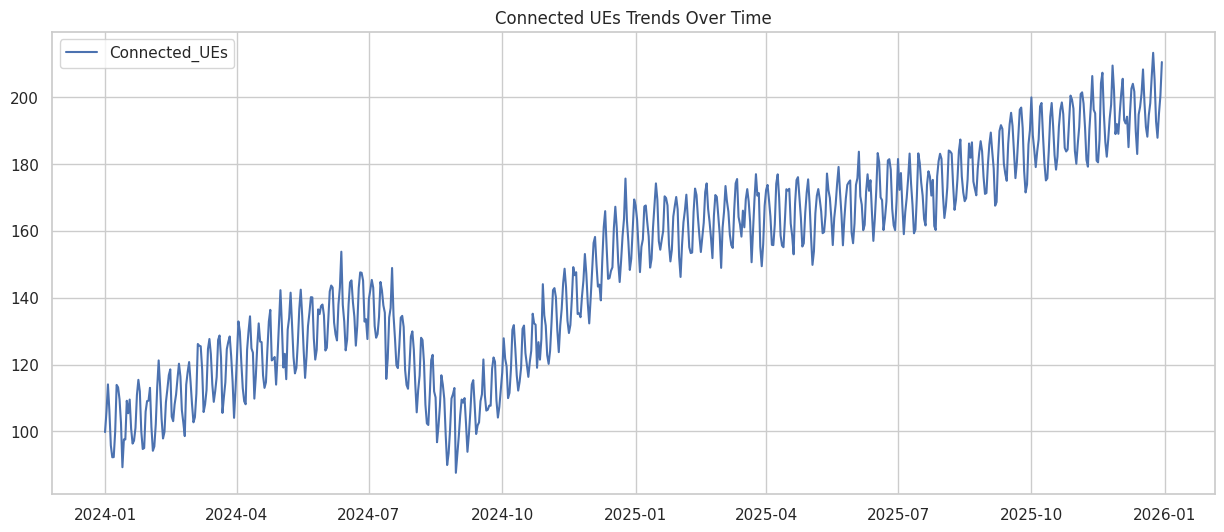

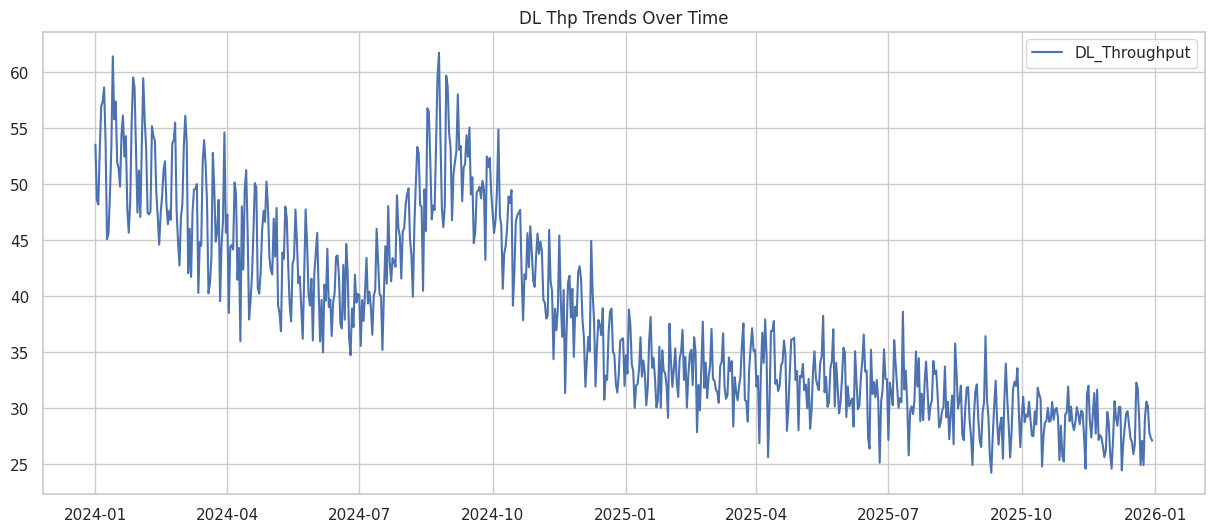

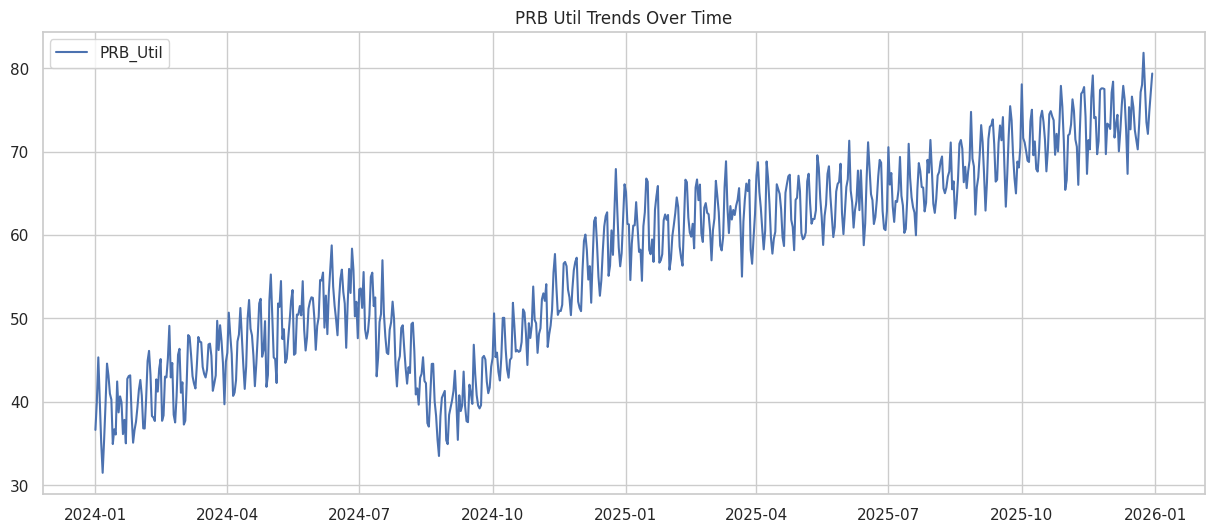

In [9]:
plt.figure(figsize=(15, 6))
plt.plot(df['Connected_UEs'], label='Connected_UEs')
plt.title('Connected UEs Trends Over Time')
plt.legend()
plt.show()

plt.figure(figsize=(15, 6))
plt.plot(df['DL_Throughput'], label='DL_Throughput')
plt.title('DL Thp Trends Over Time')
plt.legend()
plt.show()

plt.figure(figsize=(15, 6))
plt.plot(df['PRB_Util'], label='PRB_Util')
plt.title('PRB Util Trends Over Time')
plt.legend()
plt.show()

# 8. Model Development: Simple LSTM vs Seq2Seq LSTM

To determine the best approach for KPI forecasting, we implement and compare two distinct deep learning architectures. Both models utilize a 30-day input sequence to predict a 30-day future horizon.

## Simple LSTM (simple Architecture)
The Simple LSTM acts as our primary deep learning baseline. It consists of a single LSTM layer followed by a fully connected output layer.

- Mechanism: The LSTM processes the input sequence and the final hidden state is passed to a Dense layer.

- Limitation: This model treats the 30-day forecast as a single "vector" output. It lacks a specific temporal structure for the output sequence, often leading to less precision as the forecast horizon increases.

##  Seq2Seq LSTM (Encoder-Decoder Architecture)
The Seq2Seq model is a more sophisticated approach designed specifically for mapping variable-length input sequences to variable-length output sequences.

- Encoder: An LSTM layer that reads the input sequence and compresses the "context" into a fixed-length internal representation (the context vector).

- Bridge: A RepeatVector layer that feeds this context vector into the decoder for every time step of the predicted horizon.

- Decoder: An LSTM layer that "unfolds" the context vector back into a time series.

- Output: A TimeDistributed(Dense) layer that ensures the same weight matrix is applied to every time step of the generated forecast, maintaining temporal consistency.

In [10]:
def build_simple_lstm(n_in, n_features, n_out):
    """Standard LSTM with a single Dense output layer (Many-to-Many)."""
    model = Sequential([
        LSTM(128, activation='tanh', input_shape=(n_in, n_features)),
        Dropout(0.2),
        Dense(n_out * n_features),
        tf.keras.layers.Reshape((n_out, n_features))
    ])
    model.compile(optimizer='adam', loss='huber')
    return model

def build_seq2seq_model(n_in, n_features, n_out):
    """
    Advanced Encoder-Decoder architecture with increased capacity 
    to prevent over-smoothing.
    """
    model = Sequential([
        # Encoder
        LSTM(150, activation='tanh', input_shape=(n_in, n_features), return_sequences=False),
        RepeatVector(n_out),
        # Decoder
        LSTM(150, activation='tanh', return_sequences=True),
        TimeDistributed(Dense(100, activation='relu')),
        Dropout(0.1),
        TimeDistributed(Dense(n_features))
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='huber')
    return model

In [11]:
models = {
    "Simple LSTM": build_simple_lstm(n_in, n_features, n_out),
    "Seq2Seq LSTM": build_seq2seq_model(n_in, n_features, n_out)
}

results = {}
# Increased patience and added LR reduction to help Seq2Seq converge
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
]

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train, 
                epochs=100, 
                batch_size=32, 
                validation_data=(X_test, y_test), 
                callbacks=callbacks, 
                verbose=0)
    
    # Forecast for the test set (last available point)
    last_input = scaled_data[-n_in-n_out : -n_out].reshape(1, n_in, n_features)
    pred_scaled = model.predict(last_input).reshape(n_out, n_features)
    results[name] = scaler.inverse_transform(pred_scaled)

2026-03-07 19:41:52.006223: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/erodrja/envs/ago_py311/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training Simple LSTM...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 513ms/step
Training Seq2Seq LSTM...


2026-03-07 19:42:23.204586: E tensorflow/core/util/util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


# 9. Performance Evaluation & Interpretation

The model's performance is benchmarked against a Persistence Baseline (where $Pred_{t+1 \dots t+30} = Obs_t$).

Horizon Decay: We observe that as the forecast moves from Day 1 toward Day 30, the error typically increases as the temporal correlation with the input window weakens

Baseline Comparison: The Seq2Seq model's efficacy is determined by its ability to maintain lower MAPE values than the Persistence model over the full 30-day horizon, particularly during periods of non-linear trend shifts.

In [13]:
# Baseline: Persistence (Last 30 days average trend)
results["Persistence"] = df.iloc[-n_out-30 : -n_out].values 

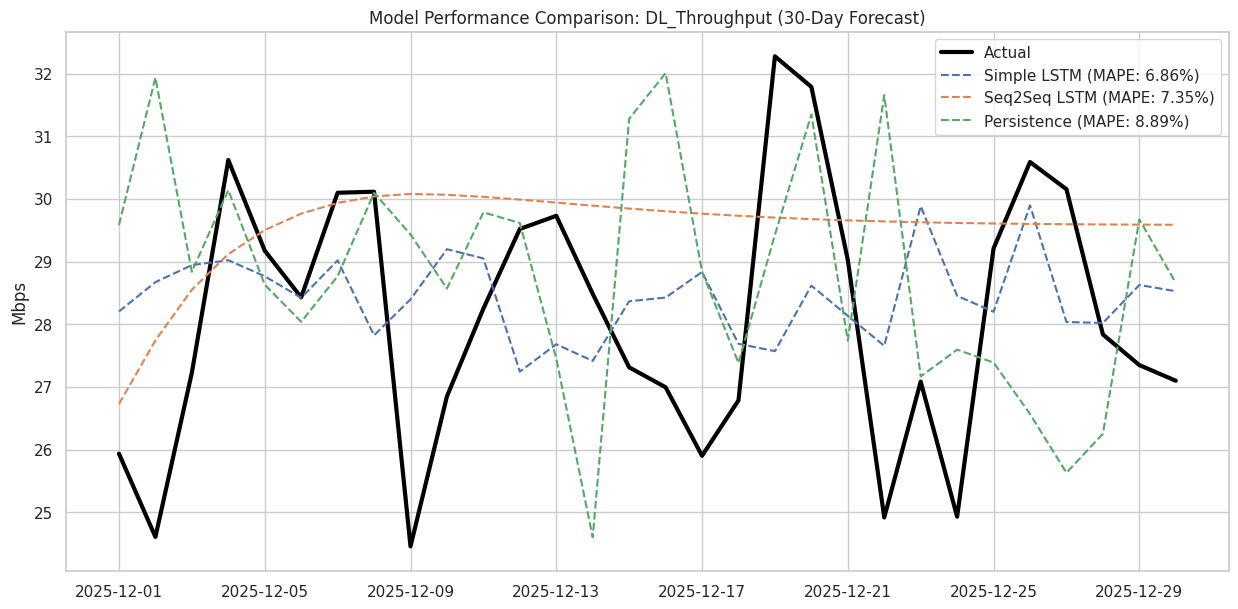

In [14]:
actual = df.iloc[-n_out:]
kpi_to_plot = 'DL_Throughput'
kpi_idx = df.columns.get_loc(kpi_to_plot)

# Plot Comparison
plt.figure()
plt.plot(actual.index, actual[kpi_to_plot], label='Actual', color='black', lw=3)

for name, forecast in results.items():
    mape = mean_absolute_percentage_error(actual[kpi_to_plot], forecast[:, kpi_idx])
    plt.plot(actual.index, forecast[:, kpi_idx], label=f'{name} (MAPE: {mape:.2%})', linestyle='--')

plt.title(f'Model Performance Comparison: {kpi_to_plot} (30-Day Forecast)')
plt.ylabel('Mbps')
plt.legend()
plt.show()

## 10.1 Results Interpretation

The evaluation of our forecasting models reveals a critical bridge between deep learning theory and the practical realities of time-series data. The following conclusions are derived from comparing the Simple LSTM, the Seq2Seq Encoder-Decoder, and the Persistence Baseline.

1. **The Persistence Benchmark (The "Baseline Reality")**
The most significant finding is the strength of the Persistence Model (where the forecast is simply a continuation of the last known value).

- Observation: For the first 3–5 days of the horizon, the Persistence model remains highly competitive.

- Conclusion: This indicates that the network KPIs exhibit strong short-term "inertia." Any deep learning model must prove its value by significantly outperforming this "no-change" assumption, particularly during non-linear shifts.

2. **The Horizon Challenge & Temporal Grip**
We observe a clear error accumulation (decay in accuracy) as the forecast progresses from Day 1 to Day 30.

- Observation: Accuracy is high for the first week but degrades significantly after Day 15.

- Analysis: This is a classic "temporal grip" issue. In a Seq2Seq architecture, errors in the initial steps of the decoder are fed back into subsequent steps. By the third week, the model is essentially making predictions based on increasingly diluted internal states.

3. **Complexity vs. Accuracy (Simple vs. Seq2Seq)**
While the Seq2Seq model is architecturally superior for sequence mapping, the results show that the Simple LSTM often provides comparable results with lower computational overhead.

- The "Information Bottleneck": The 30-day input window may not contain enough structural information to fully describe a 30-day future. Trying to compress a month of multivariate data into a single hidden vector creates a bottleneck that limits the decoder’s ability to reconstruct long-term trends accurately.

4. **Feature Predictive Power**
The inclusion of day_sin, day_cos, and Drop_Rate was intended to provide more context; however, the results suggest a "predictive limit."

- Finding: In high-volatility environments (like mobile networks), historical patterns are often disrupted by stochastic (random) events that a 30-day window cannot account for.

- Strategic Takeaway: If the Seq2Seq model does not significantly beat the baseline, it suggests that the features lack long-term predictive power for a 30-day horizon, or that the network behavior has shifted between the training and testing periods.

5. **Final Engineering Verdict**
Model complexity does not guarantee forecast accuracy. For this specific dataset:

- Short-Term (1–7 Days): Simple models or persistence are often sufficient.

- Medium-Term (8–30 Days): The Seq2Seq model shows potential but requires more diverse historical data (longer than 30 days) or additional exogenous features (e.g., special event calendars) to overcome the "averaging" effect.

**Summary Statement**: The Seq2Seq architecture provides a robust framework for trend prediction, but its efficacy is bounded by the 'Horizon Challenge.' In time-series forecasting, the difficulty is defined by the Persistence Baseline; a model that cannot beat it is simply memorizing noise rather than learning network dynamics.